# 1. Data Processing

Notebook unificado para ejecutar en orden:
1. LimpiezaDatos
2. ColumnDeleter
3. CambiosAVG

Este flujo usa DataFrames en memoria entre secciones y solo guarda el CSV final.

## Section 0 


In [ ]:
import os
import re
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)

# =========================
# CONFIG GLOBAL
# =========================
DATASETS_DIR = "datasets"
os.makedirs(DATASETS_DIR, exist_ok=True)

CSV_IN = os.path.join(DATASETS_DIR, "replays_2v2_10000_full.csv")
CSV_OUT = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

THRESHOLD_NULL_RATIO = 0.0001
TREAT_EMPTY_STRINGS_AS_NULL = True
KEEP_COLS = []
SHOW_EXAMPLES = 5
MAX_PRINT_CANDIDATES = 80  # Reducido para salida final mas limpia.
DROP_CAMERA_COLUMNS = True
DROP_MATCHES_SHORTER_THAN_SECONDS = 3

# Persistencia de decisiones de la seccion 2.5
DECISIONS_25_FILE = os.path.join(DATASETS_DIR, "section_2_5_decisions.json")

DURATION_CANDIDATES = [
    "duration",
    "duration_seconds",
    "game.duration",
    "game.duration_seconds",
    "replay.duration",
    "replay.duration_seconds",
    "match.duration",
    "match.duration_seconds",
]

print(f"CSV_IN:  {CSV_IN}")
print(f"CSV_OUT: {CSV_OUT}")
print(f"DECISIONS_25_FILE: {DECISIONS_25_FILE}")

CSV_IN:  datasets\replays_2v2_10000_full.csv
CSV_OUT: datasets\replays_subset_with_time_percentages.csv
DECISIONS_25_FILE: datasets\section_2_5_decisions.json


In [8]:
# =========================
# HELPERS COMPARTIDOS
# =========================
def read_csv_safely(path: str) -> pd.DataFrame:
    try:
        return pd.read_csv(path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1", low_memory=False)


def to_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def is_numeric_dtype(dtype) -> bool:
    return pd.api.types.is_numeric_dtype(dtype)


def is_bool_dtype(dtype) -> bool:
    return pd.api.types.is_bool_dtype(dtype)


def shorten(x, n=180):
    s = str(x)
    return s if len(s) <= n else s[:n] + "..."


def print_examples(series: pd.Series, n=5):
    non_null = series.dropna()
    if non_null.empty:
        print("  (no hay valores no nulos para mostrar)")
        return
    for i, v in enumerate(non_null.head(n).tolist(), start=1):
        print(f"  {i}. {shorten(v)}")


def ask_action(col: str, null_pct: float, dtype: str) -> str:
    while True:
        print("\n----------------------------------------")
        print(f"Columna candidata: {col}")
        print(f"  - null_pct: {null_pct:.2f}%")
        print(f"  - dtype: {dtype}")
        ans = input("Accion: [d]=eliminar, [k]=mantener y rellenar nulls, [s]=ver ejemplos, [q]=salir: ").strip().lower()
        if ans in {"d", "k", "s", "q"}:
            return ans
        print("Entrada no valida. Usa d/k/s/q.")


def ask_imputation_numeric(col: str, series: pd.Series) -> tuple[str, object]:
    while True:
        print("\nRelleno de nulls (columna numerica):")
        print("  [1] media")
        print("  [2] mediana")
        print("  [3] moda (valor mas frecuente)")
        print("  [4] constante (lo indicas tu)")
        print("  [5] cero")
        print("  [6] no rellenar (dejar nulls)")
        choice = input("Elige 1/2/3/4/5/6: ").strip()

        s = series.dropna()
        if choice == "1":
            if s.empty:
                print("No hay datos no nulos para calcular media. Elige constante.")
                continue
            return ("mean", float(s.mean()))
        if choice == "2":
            if s.empty:
                print("No hay datos no nulos para calcular mediana. Elige constante.")
                continue
            return ("median", float(s.median()))
        if choice == "3":
            if s.empty:
                print("No hay datos no nulos para calcular moda. Elige constante.")
                continue
            mode = s.mode(dropna=True)
            if mode.empty:
                print("No se pudo calcular moda. Elige constante.")
                continue
            try:
                return ("mode", float(mode.iloc[0]))
            except Exception:
                return ("mode", mode.iloc[0])
        if choice == "4":
            raw = input(f"Valor constante para '{col}' (ej: 0, -1, 3.14): ").strip()
            try:
                val = float(raw)
            except ValueError:
                print("Ese valor no parece numerico. Intenta de nuevo.")
                continue
            return ("constant", val)
        if choice == "5":
            return ("zero", 0.0)
        if choice == "6":
            return ("none", None)
        print("Opcion no valida.")


def ask_imputation_bool(col: str, series: pd.Series) -> tuple[str, object]:
    while True:
        print("\nRelleno de nulls (columna booleana):")
        print("  [1] True")
        print("  [2] False")
        print("  [3] moda (valor mas frecuente)")
        print("  [4] no rellenar (dejar nulls)")
        choice = input("Elige 1/2/3/4: ").strip()

        s = series.dropna()
        if choice == "1":
            return ("true", True)
        if choice == "2":
            return ("false", False)
        if choice == "3":
            if s.empty:
                print("No hay datos no nulos para calcular moda. Elige True/False.")
                continue
            mode = s.mode(dropna=True)
            if mode.empty:
                print("No se pudo calcular moda. Elige True/False.")
                continue
            return ("mode", bool(mode.iloc[0]))
        if choice == "4":
            return ("none", None)
        print("Opcion no valida.")


def ask_imputation_categorical(col: str, series: pd.Series) -> tuple[str, object]:
    while True:
        print("\nRelleno de nulls (columna no numerica):")
        print("  [1] moda (valor mas frecuente)")
        print("  [2] constante (lo indicas tu, texto)")
        print("  [3] 'MISSING' (texto literal)")
        print("  [4] cadena vacia ''")
        print("  [5] boolean True")
        print("  [6] boolean False")
        print("  [7] no rellenar (dejar nulls)")
        choice = input("Elige 1/2/3/4/5/6/7: ").strip()

        s = series.dropna()
        if choice == "1":
            if s.empty:
                print("No hay datos no nulos para calcular moda. Elige constante.")
                continue
            mode = s.mode(dropna=True)
            if mode.empty:
                print("No se pudo calcular moda. Elige constante.")
                continue
            return ("mode", str(mode.iloc[0]))
        if choice == "2":
            val = input(f"Valor constante (texto) para '{col}': ").strip()
            return ("constant", val)
        if choice == "3":
            return ("missing_literal", "MISSING")
        if choice == "4":
            return ("empty_string", "")
        if choice == "5":
            return ("true", True)
        if choice == "6":
            return ("false", False)
        if choice == "7":
            return ("none", None)
        print("Opcion no valida.")


def _to_python_scalar(value):
    if value is None:
        return None
    if pd.isna(value):
        return None
    if isinstance(value, np.generic):
        return value.item()
    return value


def load_decisions(path: str) -> dict:
    if not os.path.exists(path):
        return {}
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        return {}
    return data


def save_decisions(path: str, decisions: dict) -> None:
    serializable = {}
    for col, payload in decisions.items():
        if not isinstance(payload, dict):
            continue
        action = payload.get("action")
        if action == "drop":
            serializable[col] = {"action": "drop"}
        elif action == "impute":
            serializable[col] = {
                "action": "impute",
                "strategy": payload.get("strategy", "none"),
                "value": _to_python_scalar(payload.get("value")),
            }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(serializable, f, ensure_ascii=True, indent=2)


def apply_saved_decisions(df_in: pd.DataFrame, decisions: dict) -> tuple[pd.DataFrame, list[str], dict[str, tuple[str, object]]]:
    dropped_cols = []
    imputed_cols = {}
    df_out = df_in.copy()

    for col, payload in decisions.items():
        if col not in df_out.columns:
            continue
        action = payload.get("action")

        if action == "drop":
            dropped_cols.append(col)
            continue

        if action == "impute":
            strat = payload.get("strategy", "none")
            val = payload.get("value")
            if strat != "none":
                df_out[col] = df_out[col].fillna(val)
            preview = shorten(val, 60) if isinstance(val, str) else val
            imputed_cols[col] = (strat, preview)

    if dropped_cols:
        cols_to_drop = [c for c in dropped_cols if c in df_out.columns]
        df_out = df_out.drop(columns=cols_to_drop)

    return df_out, dropped_cols, imputed_cols


def is_camera_col(col: str) -> bool:
    c = col.lower()

    camera_keywords = [
        "camera", "camera_settings", "cam_settings", "camerasettings", "camsettings"
    ]
    if any(k in c for k in camera_keywords):
        return True

    cam_params = ["fov", "distance", "height", "angle", "stiffness", "swivel", "transition"]
    if any(p in c for p in cam_params) and ("player" in c or "players" in c) and ("setting" in c or "settings" in c):
        return True

    return False


def find_duration_column(df: pd.DataFrame) -> str | None:
    for c in DURATION_CANDIDATES:
        if c in df.columns:
            return c
    duration_like = [c for c in df.columns if "duration" in c.lower()]
    if duration_like:
        for c in duration_like:
            if "second" in c.lower():
                return c
        return duration_like[0]
    return None


def rank_name_without_division(value):
    if value is None or pd.isna(value):
        return pd.NA
    s = str(value).strip()
    if not s:
        return pd.NA
    s = re.sub(r"\s+Division\s+\d+\s*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\s+(I|II|III)\s*$", "", s, flags=re.IGNORECASE)
    return s.strip()


def add_grouped_game_rank_columns(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    mapping = [
        ("min_rank.name", "min.game.rank"),
        ("max_rank.name", "max.game.rank"),
    ]

    for src_col, dst_col in mapping:
        if src_col not in df_out.columns:
            print(f"[WARN] No existe columna fuente para rank agrupado: {src_col}")
            continue
        df_out[dst_col] = df_out[src_col].apply(rank_name_without_division).astype("string")

    return df_out

In [11]:
# Docstrings breves para funciones helper existentes (sin alterar logica).
helper_docstrings = {
    "read_csv_safely": "Read CSV with utf-8 fallback to latin-1 when needed.",
    "to_numeric": "Convert a pandas Series to numeric values with coercion.",
    "is_numeric_dtype": "Return whether dtype is numeric.",
    "is_bool_dtype": "Return whether dtype is boolean.",
    "shorten": "Truncate long values for cleaner logging output.",
    "print_examples": "Print a sample of non-null values from a Series.",
    "ask_action": "Prompt user action for candidate column treatment.",
    "ask_imputation_numeric": "Interactively choose numeric imputation strategy and value.",
    "ask_imputation_bool": "Interactively choose boolean imputation strategy and value.",
    "ask_imputation_categorical": "Interactively choose categorical imputation strategy and value.",
    "_to_python_scalar": "Convert numpy/pandas scalar values to Python-native scalars.",
    "load_decisions": "Load saved cleaning decisions from JSON file.",
    "save_decisions": "Persist cleaning decisions to JSON file.",
    "apply_saved_decisions": "Apply stored drop/imputation decisions to a DataFrame.",
    "is_camera_col": "Detect camera-related columns by naming patterns.",
    "find_duration_column": "Find the most suitable duration column in a DataFrame.",
    "rank_name_without_division": "Normalize rank labels by removing division suffixes.",
    "add_grouped_game_rank_columns": "Create grouped rank columns from source rank fields.",
}

for func_name, doc in helper_docstrings.items():
    if func_name in globals() and callable(globals()[func_name]):
        globals()[func_name].__doc__ = doc

print(f"Docstrings aplicados a helpers detectados: {sum(name in globals() for name in helper_docstrings)}")

Docstrings aplicados a helpers detectados: 18


## Section 1 - Limpieza automatica (en memoria)

Esta seccion carga el CSV inicial y aplica limpieza automatica (camara y duracion).

In [4]:
if not os.path.exists(CSV_IN):
    raise FileNotFoundError(f"No existe el archivo: {CSV_IN}")

df = read_csv_safely(CSV_IN)

if TREAT_EMPTY_STRINGS_AS_NULL:
    df = df.replace(r"^\s*$", pd.NA, regex=True)

rows_before_all = len(df)
cols_before_all = df.shape[1]

print("========================================")
print("Carga inicial")
print("========================================")
print(f"Filas iniciales:    {rows_before_all:,}")
print(f"Columnas iniciales: {cols_before_all:,}")

Carga inicial
Filas iniciales:    10,000
Columnas iniciales: 561


Analisis de datos faltantes (pre-procesamiento)


,feature,null_count,null_pct
0,blue.players.1.mvp,9999,99.99
1,orange.name,9999,99.99
2,orange.players.0.id.player_number,9981,99.81
3,groups.0.link,9980,99.80
4,groups.0.name,9980,99.80
...,...,...,...
556,blue.players.0.end_time,0,0.00
557,blue.players.0.car_id,0,0.00
558,blue.players.0.camera.transition_speed,0,0.00
559,blue.players.0.camera.swivel_speed,0,0.00


Mostrando top 40 columnas con mayor % de nulos.


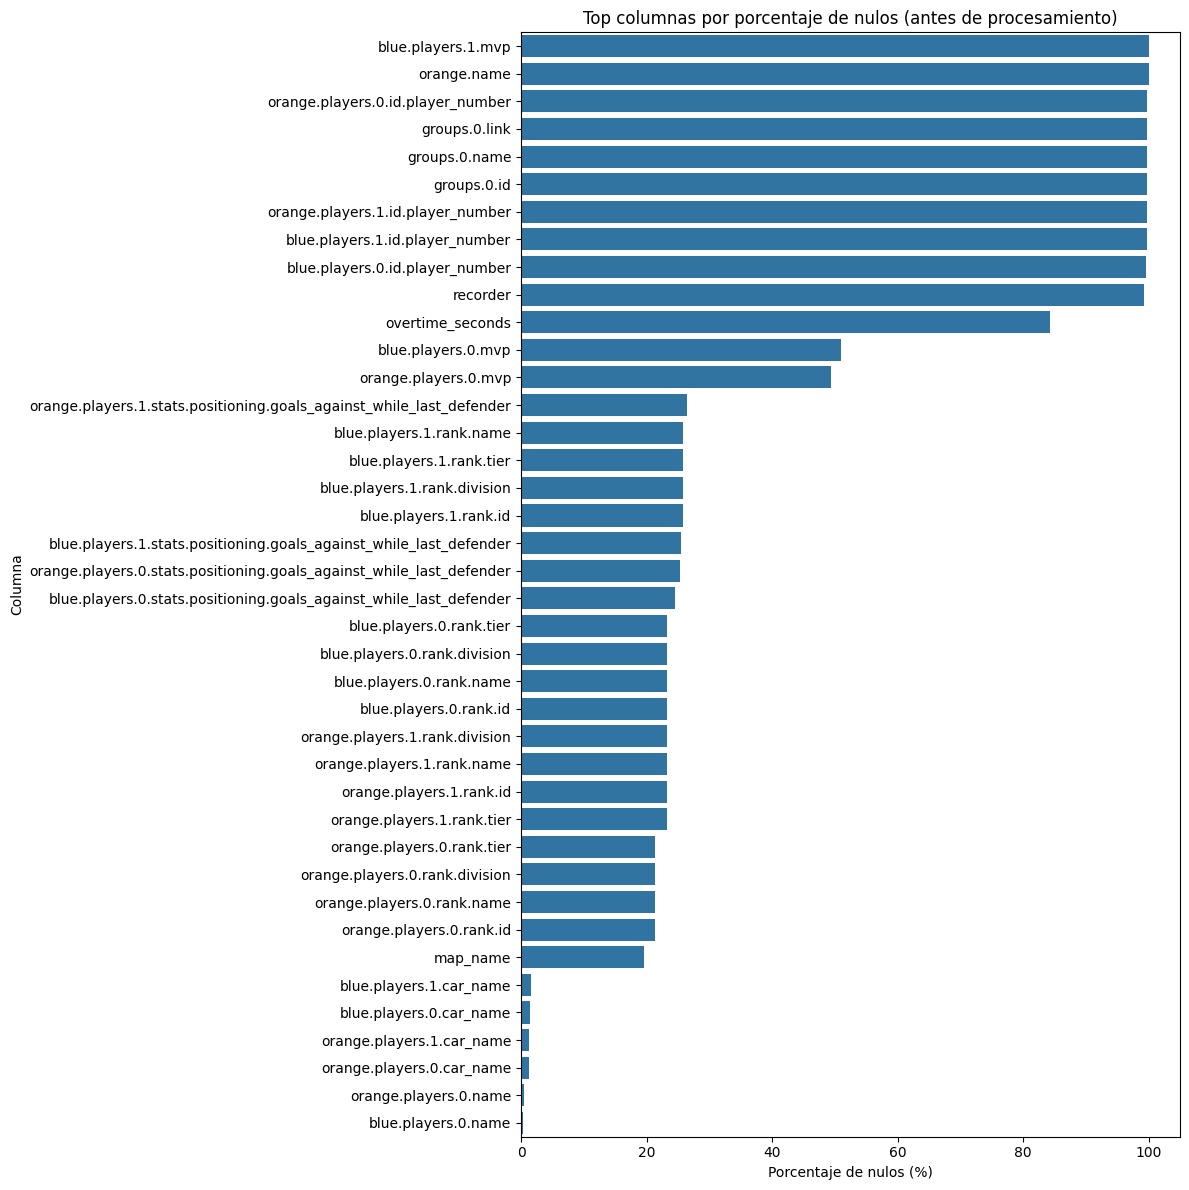


Distribucion de la clase objetivo (pre-procesamiento)
Target usado: max.game.rank
Numero de clases: 6
Conteo clase minoritaria: 3
Conteo clase mayoritaria: 4,351
Minority ratio (minority/majority): 0.0007


,target_class,count
0,Champion,4351
1,Grand Champion,4210
2,Diamond,1196
3,Platinum,195
4,Gold,45
5,Silver,3


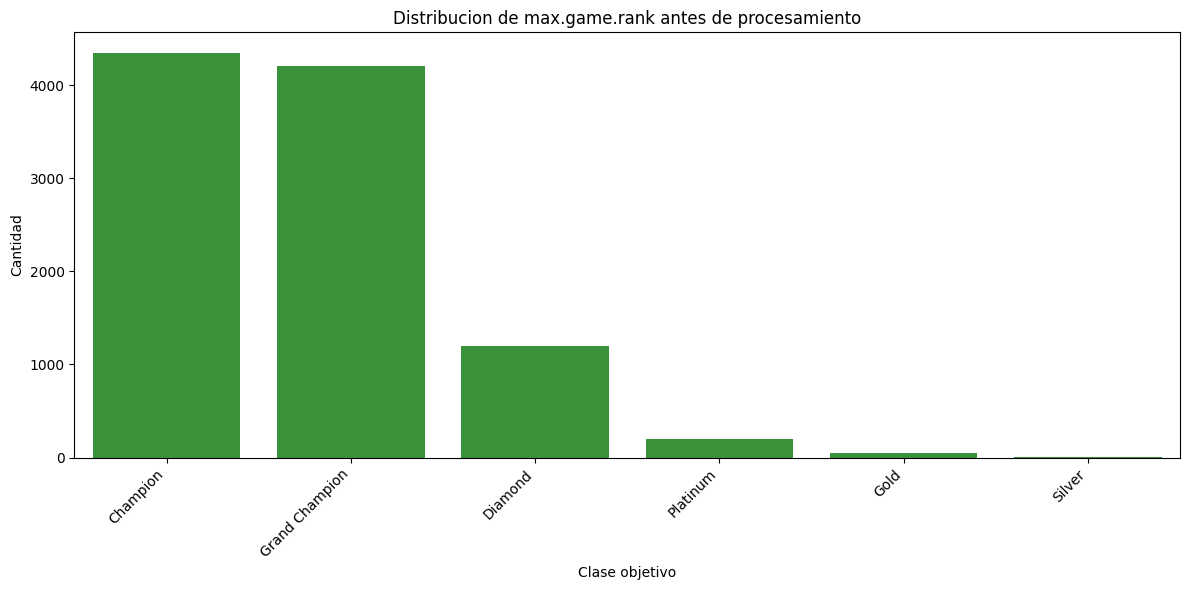

In [9]:
# =========================
# ANALISIS DE NULOS (ANTES DE PROCESAMIENTO)
# =========================
null_summary_df = (
    df.isna()
    .sum()
    .rename("null_count")
    .to_frame()
    .assign(null_pct=lambda d: (d["null_count"] / len(df)) * 100.0)
    .reset_index()
    .rename(columns={"index": "feature"})
    .sort_values("null_pct", ascending=False)
    .reset_index(drop=True)
)

print("========================================")
print("Analisis de datos faltantes (pre-procesamiento)")
print("========================================")
display(null_summary_df)

null_nonzero_df = null_summary_df[null_summary_df["null_count"] > 0].copy()
TOP_N_NULL_PLOT = 40

if null_nonzero_df.empty:
    print("No se detectaron columnas con valores nulos.")
else:
    null_plot_df = null_nonzero_df.head(TOP_N_NULL_PLOT).copy()
    print(f"Mostrando top {len(null_plot_df):,} columnas con mayor % de nulos.")
    plt.figure(figsize=(12, max(6, len(null_plot_df) * 0.3)))
    sns.barplot(data=null_plot_df, x="null_pct", y="feature", color="#1f77b4")
    plt.xlabel("Porcentaje de nulos (%)")
    plt.ylabel("Columna")
    plt.title("Top columnas por porcentaje de nulos (antes de procesamiento)")
    plt.tight_layout()
    plt.show()

# =========================
# DISTRIBUCION DEL TARGET (ANTES DE PROCESAMIENTO)
# =========================
# Requisito del proyecto: visualizar especificamente max.game.rank antes del procesamiento.
if "max.game.rank" in df.columns:
    target_series_raw = df["max.game.rank"]
elif "max_rank.name" in df.columns:
    if "rank_name_without_division" in globals():
        target_series_raw = df["max_rank.name"].apply(rank_name_without_division)
    else:
        target_series_raw = df["max_rank.name"].astype("string").str.replace(
            r"\s+Division\s+\d+\s*$",
            "",
            regex=True,
        )
else:
    raise KeyError(
        "No se encontro una fuente para construir max.game.rank (se esperaba max.game.rank o max_rank.name)."
    )

target_col_raw = "max.game.rank"
target_series_raw = target_series_raw.fillna("MISSING").astype("string")
target_counts_raw = target_series_raw.value_counts(dropna=False).sort_values(ascending=False)

if target_counts_raw.empty:
    minority_count = 0
    majority_count = 0
    minority_ratio = np.nan
else:
    minority_count = int(target_counts_raw.min())
    majority_count = int(target_counts_raw.max())
    minority_ratio = (minority_count / majority_count) if majority_count > 0 else np.nan

print("\n========================================")
print("Distribucion de la clase objetivo (pre-procesamiento)")
print("========================================")
print(f"Target usado: {target_col_raw}")
print(f"Numero de clases: {len(target_counts_raw):,}")
print(f"Conteo clase minoritaria: {minority_count:,}")
print(f"Conteo clase mayoritaria: {majority_count:,}")
print(
    f"Minority ratio (minority/majority): {minority_ratio:.4f}"
    if pd.notna(minority_ratio)
    else "Minority ratio (minority/majority): NaN"
)

target_dist_df = target_counts_raw.rename_axis("target_class").reset_index(name="count")
display(target_dist_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=target_dist_df, x="target_class", y="count", color="#2ca02c")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Clase objetivo")
plt.ylabel("Cantidad")
plt.title("Distribucion de max.game.rank antes de procesamiento")
plt.tight_layout()
plt.show()

In [12]:
# Visualizacion de faltantes para reporte final (solo missingno.matrix, sin heatmap).
if "df" not in globals():
    raise NameError("No existe 'df'. Ejecuta la carga de datos primero.")

null_ratio_series = df.isna().mean().sort_values(ascending=False)
top_null_cols = null_ratio_series[null_ratio_series > 0].head(30).index.tolist()

if not top_null_cols:
    print("No se detectaron columnas con valores faltantes para visualizar.")
else:
    try:
        import missingno as msno

        print("Mostrando missingno.matrix para las 30 columnas con mas nulos.")
        msno.matrix(df[top_null_cols], figsize=(12, 5), sparkline=False)
        plt.title("Missing Values Matrix (Top 30 columnas con nulos)")
        plt.show()
    except ImportError:
        print("missingno no esta instalado. Se omite la visualizacion de nulos porque heatmap fue removido.")

missingno no esta instalado. Se omite la visualizacion de nulos porque heatmap fue removido.


In [ ]:
# 0) Eliminacion automatica de columnas de camara
if DROP_CAMERA_COLUMNS:
    camera_cols = [c for c in df.columns if is_camera_col(c)]
    print("\n========================================")
    print("Eliminacion automatica: columnas de camara")
    print("========================================")
    if camera_cols:
        print(f"Columnas detectadas: {len(camera_cols):,}")
        for c in camera_cols:
            print(f"- {c}")
        df = df.drop(columns=camera_cols)
    else:
        print("No se detectaron columnas de camara con el patron actual.")

# 1) Eliminacion automatica de partidas cortas
if DROP_MATCHES_SHORTER_THAN_SECONDS is not None:
    print("\n========================================")
    print(f"Eliminacion automatica: partidas < {DROP_MATCHES_SHORTER_THAN_SECONDS}s")
    print("========================================")
    dur_col = find_duration_column(df)
    if dur_col is None:
        print("No se encontro columna de duracion. No se eliminan filas por duracion.")
        duration_like = [c for c in df.columns if "duration" in c.lower()]
        if duration_like:
            print("Columnas con 'duration':")
            for c in duration_like[:50]:
                print(f"- {c}")
            if len(duration_like) > 50:
                print(f"... ({len(duration_like) - 50} mas)")
        else:
            print("(ninguna)")
    else:
        dur = pd.to_numeric(df[dur_col], errors="coerce")
        mask_short = dur.notna() & (dur < DROP_MATCHES_SHORTER_THAN_SECONDS)
        removed_short = int(mask_short.sum())
        df = df.loc[~mask_short].copy()

        print(f"Columna usada: {dur_col}")
        print(f"Filas eliminadas por duracion: {removed_short:,}")
        print(f"Filas restantes: {len(df):,}")

print("\n========================================")
print("Section 1 completada (limpieza automatica)")
print("========================================")
print(f"Filas tras limpieza automatica:    {len(df):,}")
print(f"Columnas tras limpieza automatica: {df.shape[1]:,}")

df_stage1 = df.copy()


Eliminacion automatica: columnas de camara
Columnas detectadas: 28
- blue.players.0.camera.distance
- blue.players.0.camera.fov
- blue.players.0.camera.height
- blue.players.0.camera.pitch
- blue.players.0.camera.stiffness
- blue.players.0.camera.swivel_speed
- blue.players.0.camera.transition_speed
- blue.players.1.camera.distance
- blue.players.1.camera.fov
- blue.players.1.camera.height
- blue.players.1.camera.pitch
- blue.players.1.camera.stiffness
- blue.players.1.camera.swivel_speed
- blue.players.1.camera.transition_speed
- orange.players.0.camera.distance
- orange.players.0.camera.fov
- orange.players.0.camera.height
- orange.players.0.camera.pitch
- orange.players.0.camera.stiffness
- orange.players.0.camera.swivel_speed
- orange.players.0.camera.transition_speed
- orange.players.1.camera.distance
- orange.players.1.camera.fov
- orange.players.1.camera.height
- orange.players.1.camera.pitch
- orange.players.1.camera.stiffness
- orange.players.1.camera.swivel_speed
- orange.pl

## Section 2 - ColumnDeleter (en memoria)

Primero se aplica la lista corregida de columnas para reducir trabajo innecesario antes de la imputacion interactiva.

In [ ]:
def build_keep_columns() -> list[str]:
    keep = set()

    keep.update([
        "duration",
        "overtime",
        "overtime_seconds",
        "max.game.rank",
        "server.region",
        "blue",
        "orange",
        "blue.color",
        "orange.color",
        "blue.players",
        "orange.players",
        "blue.stats",
        "orange.stats",
        "blue.stats.ball",
        "orange.stats.ball",
        "blue.stats.core",
        "orange.stats.core",
        "blue.stats.boost",
        "orange.stats.boost",
        "blue.stats.movement",
        "orange.stats.movement",
        "blue.stats.positioning",
        "orange.stats.positioning",
        "blue.stats.demo",
        "orange.stats.demo",
    ])

    teams = ["blue", "orange"]
    team_ball = ["possession_time", "time_in_side"]
    for t in teams:
        for f in team_ball:
            keep.add(f"{t}.stats.ball.{f}")

    team_core = [
        "shots", "shots_against", "goals", "goals_against", "saves", "assists", "score", "shooting_percentage"
    ]

    team_boost = [
        "bpm", "bcpm", "avg_amount",
        "amount_collected", "amount_stolen",
        "amount_collected_big", "amount_stolen_big",
        "amount_collected_small", "amount_stolen_small",
        "count_collected_big", "count_stolen_big",
        "count_collected_small", "count_stolen_small",
        "amount_overfill", "amount_overfill_stolen",
        "amount_used_while_supersonic",
        "time_zero_boost", "time_full_boost",
        "time_boost_0_25", "time_boost_25_50", "time_boost_50_75", "time_boost_75_100",
    ]

    team_movement = [
        "total_distance",
        "time_supersonic_speed", "time_boost_speed", "time_slow_speed",
        "time_ground", "time_low_air", "time_high_air",
        "time_powerslide", "count_powerslide",
    ]

    team_positioning = [
        "time_defensive_third",
        "time_neutral_third",
        "time_offensive_third",
        "time_defensive_half",
        "time_offensive_half",
        "time_behind_ball",
        "time_infront_ball",
    ]

    team_demo = ["inflicted", "taken"]

    for t in teams:
        for f in team_core:
            keep.add(f"{t}.stats.core.{f}")
        for f in team_boost:
            keep.add(f"{t}.stats.boost.{f}")
        for f in team_movement:
            keep.add(f"{t}.stats.movement.{f}")
        for f in team_positioning:
            keep.add(f"{t}.stats.positioning.{f}")
        for f in team_demo:
            keep.add(f"{t}.stats.demo.{f}")

    return sorted(keep)


if "df_stage1" in globals():
    df = df_stage1.copy()
elif "df" in globals():
    print("[WARN] df_stage1 no existe. Usando el DataFrame actual 'df'.")
    df = df.copy()
else:
    raise NameError("df_stage1 no esta definido. Ejecuta la celda de Section 1 antes de Section 2.")
df = add_grouped_game_rank_columns(df)
keep_cols = build_keep_columns()

existing = [c for c in keep_cols if c in df.columns]
existing = [
    c for c in existing
    if ".players." not in c
    or (".id" not in c and not c.endswith(".name"))
]
missing = [c for c in keep_cols if c not in df.columns]

print("========================================")
print("Section 2 - Seleccion de columnas")
print("========================================")
print(f"Filas actuales:      {len(df):,}")
print(f"Columnas actuales:   {df.shape[1]:,}")
print(f"Cols solicitadas:    {len(keep_cols):,}")
print(f"Cols encontradas:    {len(existing):,}")
print(f"Cols faltantes:      {len(missing):,}")

if missing:
    print("\nColumnas solicitadas que no existen:")
    for c in missing:
        print(f"- {c}")

df = df[existing].copy()
df_stage2 = df.copy()

print(f"\nColumnas tras filtro: {df.shape[1]:,}")

Section 2 - Seleccion de columnas
Filas actuales:      10,000
Columnas actuales:   535
Cols solicitadas:    125
Cols encontradas:    107
Cols faltantes:      18

Columnas solicitadas que no existen:
- blue
- blue.players
- blue.stats
- blue.stats.ball
- blue.stats.boost
- blue.stats.core
- blue.stats.demo
- blue.stats.movement
- blue.stats.positioning
- orange
- orange.players
- orange.stats
- orange.stats.ball
- orange.stats.boost
- orange.stats.core
- orange.stats.demo
- orange.stats.movement
- orange.stats.positioning

Columnas tras filtro: 107


## Section 2.5 - Imputacion interactiva tras filtro (Appendix Verbose)

La imputacion interactiva se aplica despues de filtrar columnas para reducir entradas manuales innecesarias.

Esta seccion tambien guarda tus decisiones y, si ejecutas de nuevo, te permite preservar las decisiones anteriores o decidir otra vez.

Para lectura final del informe, puede omitirse esta seccion y usar directamente decisiones guardadas.

In [ ]:
df = df_stage2.copy()

# Robustez: permite ejecutar esta celda incluso si no se han recargado helpers/config
if "DECISIONS_25_FILE" not in globals():
    DECISIONS_25_FILE = "section_2_5_decisions.json"

if "_to_python_scalar" not in globals():
    def _to_python_scalar(value):
        if value is None:
            return None
        if pd.isna(value):
            return None
        if isinstance(value, np.generic):
            return value.item()
        return value

if "load_decisions" not in globals():
    def load_decisions(path: str) -> dict:
        if not os.path.exists(path):
            return {}
        try:
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)
            return data if isinstance(data, dict) else {}
        except Exception:
            print(f"[WARN] No se pudo leer {path}. Se usaran decisiones vacias.")
            return {}

if "save_decisions" not in globals():
    def save_decisions(path: str, decisions: dict) -> None:
        serializable = {}
        for col, payload in decisions.items():
            if not isinstance(payload, dict):
                continue
            action = payload.get("action")
            if action == "drop":
                serializable[col] = {"action": "drop"}
            elif action == "impute":
                serializable[col] = {
                    "action": "impute",
                    "strategy": payload.get("strategy", "none"),
                    "value": _to_python_scalar(payload.get("value")),
                }
        with open(path, "w", encoding="utf-8") as f:
            json.dump(serializable, f, ensure_ascii=True, indent=2)

if "apply_saved_decisions" not in globals():
    def apply_saved_decisions(df_in: pd.DataFrame, decisions: dict) -> tuple[pd.DataFrame, list[str], dict[str, tuple[str, object]]]:
        dropped_cols = []
        imputed_cols = {}
        df_out = df_in.copy()

        for col, payload in decisions.items():
            if col not in df_out.columns:
                continue
            action = payload.get("action")

            if action == "drop":
                dropped_cols.append(col)
                continue

            if action == "impute":
                strat = payload.get("strategy", "none")
                val = payload.get("value")
                if strat != "none":
                    df_out[col] = df_out[col].fillna(val)
                preview = shorten(val, 60) if isinstance(val, str) else val
                imputed_cols[col] = (strat, preview)

        if dropped_cols:
            cols_to_drop = [c for c in dropped_cols if c in df_out.columns]
            df_out = df_out.drop(columns=cols_to_drop)

        return df_out, dropped_cols, imputed_cols

saved_decisions = load_decisions(DECISIONS_25_FILE)
use_saved = False

if saved_decisions:
    print("\n========================================")
    print("Decisiones previas detectadas")
    print("========================================")
    print(f"Archivo: {DECISIONS_25_FILE}")
    print(f"Columnas con decision guardada: {len(saved_decisions):,}")

    while True:
        choice = input("Quieres preservar decisiones previas o decidir otra vez? [p]=preservar, [r]=repetir: ").strip().lower()
        if choice in {"p", "r"}:
            use_saved = (choice == "p")
            break
        print("Entrada no valida. Usa p/r.")

if use_saved:
    df, dropped_cols, imputed_cols = apply_saved_decisions(df, saved_decisions)
    decisions = saved_decisions
    print("\nSe aplicaron las decisiones guardadas.")
else:
    null_ratio = df.isna().mean()
    keep_set = set(KEEP_COLS)

    candidates = [c for c in df.columns if (null_ratio[c] > THRESHOLD_NULL_RATIO and c not in keep_set)]
    candidates.sort(key=lambda c: null_ratio[c], reverse=True)

    dropped_cols = []
    imputed_cols = {}
    decisions = {}

    print("\n========================================")
    print("Candidatas a revisar (muchos nulos)")
    print(f"Total candidatas (null_ratio > {THRESHOLD_NULL_RATIO}): {len(candidates):,}")
    print("Formato: columna | null_pct | dtype")
    print("========================================")

    if not candidates:
        print("No hay columnas candidatas. Se continua a la siguiente seccion.")
    else:
        to_show = candidates if MAX_PRINT_CANDIDATES == 0 else candidates[:MAX_PRINT_CANDIDATES]
        for col in to_show:
            print(f"{col} | {null_ratio[col]*100:.2f}% | {df[col].dtype}")
        if MAX_PRINT_CANDIDATES != 0 and len(candidates) > MAX_PRINT_CANDIDATES:
            print(f"... ({len(candidates) - MAX_PRINT_CANDIDATES} mas no mostradas)")

        input("\nPulsa ENTER para empezar a decidir columna por columna...")

        for idx, col in enumerate(candidates, start=1):
            pct = float(null_ratio[col] * 100.0)
            dtype = str(df[col].dtype)

            print(f"\n[{idx}/{len(candidates)}]")

            while True:
                action = ask_action(col, pct, dtype)

                if action == "s":
                    print("\nEjemplos (no nulos):")
                    print_examples(df[col], n=SHOW_EXAMPLES)
                    continue

                if action == "q":
                    print("Salida solicitada. No se continua la ejecucion.")
                    raise SystemExit(0)

                if action == "d":
                    dropped_cols.append(col)
                    decisions[col] = {"action": "drop"}
                    break

                if action == "k":
                    if is_bool_dtype(df[col].dtype):
                        strat, val = ask_imputation_bool(col, df[col])
                    elif is_numeric_dtype(df[col].dtype):
                        strat, val = ask_imputation_numeric(col, df[col])
                    else:
                        strat, val = ask_imputation_categorical(col, df[col].astype("string"))

                    if strat != "none":
                        df[col] = df[col].fillna(val)

                    preview = val
                    if isinstance(preview, str):
                        preview = shorten(preview, 60)
                    imputed_cols[col] = (strat, preview)
                    decisions[col] = {
                        "action": "impute",
                        "strategy": strat,
                        "value": _to_python_scalar(val),
                    }
                    break

    if dropped_cols:
        df = df.drop(columns=dropped_cols)

    save_decisions(DECISIONS_25_FILE, decisions)
    print(f"\nDecisiones guardadas en: {DECISIONS_25_FILE}")

df_stage2_clean = df.copy()

print("\n========================================")
print("Section 2.5 completada (imputacion interactiva)")
print("========================================")
print(f"Filas actuales: {len(df):,}")
print(f"Columnas actuales: {df.shape[1]:,}")
print(f"Columnas eliminadas (interactivo): {len(dropped_cols):,}")
print(f"Columnas imputadas (rellenadas): {len(imputed_cols):,}")
print(f"Total nulls restantes: {int(df.isna().sum().sum()):,}")


Decisiones previas detectadas
Archivo: datasets\section_2_5_decisions.json
Columnas con decision guardada: 5

Se aplicaron las decisiones guardadas.

Section 2.5 completada (imputacion interactiva)
Filas actuales: 10,000
Columnas actuales: 107
Columnas eliminadas (interactivo): 0
Columnas imputadas (rellenadas): 5
Total nulls restantes: 0


## Section 3 - CambiosAVG (en memoria)

Se crean columnas *_pct a partir de columnas de tiempo, usando duration como denominador.

In [ ]:
DURATION_COL = "duration"
TEAM_TIME_COLS = [
    "blue.stats.ball.possession_time",
    "blue.stats.ball.time_in_side",
    "blue.stats.boost.time_zero_boost",
    "blue.stats.boost.time_full_boost",
    "blue.stats.boost.time_boost_0_25",
    "blue.stats.boost.time_boost_25_50",
    "blue.stats.boost.time_boost_50_75",
    "blue.stats.boost.time_boost_75_100",
    "blue.stats.movement.time_supersonic_speed",
    "blue.stats.movement.time_boost_speed",
    "blue.stats.movement.time_slow_speed",
    "blue.stats.movement.time_ground",
    "blue.stats.movement.time_low_air",
    "blue.stats.movement.time_high_air",
    "blue.stats.movement.time_powerslide",
    "blue.stats.positioning.time_defensive_third",
    "blue.stats.positioning.time_neutral_third",
    "blue.stats.positioning.time_offensive_third",
    "blue.stats.positioning.time_defensive_half",
    "blue.stats.positioning.time_offensive_half",
    "blue.stats.positioning.time_behind_ball",
    "blue.stats.positioning.time_infront_ball",
    "orange.stats.ball.possession_time",
    "orange.stats.ball.time_in_side",
    "orange.stats.boost.time_zero_boost",
    "orange.stats.boost.time_full_boost",
    "orange.stats.boost.time_boost_0_25",
    "orange.stats.boost.time_boost_25_50",
    "orange.stats.boost.time_boost_50_75",
    "orange.stats.boost.time_boost_75_100",
    "orange.stats.movement.time_supersonic_speed",
    "orange.stats.movement.time_boost_speed",
    "orange.stats.movement.time_slow_speed",
    "orange.stats.movement.time_ground",
    "orange.stats.movement.time_low_air",
    "orange.stats.movement.time_high_air",
    "orange.stats.movement.time_powerslide",
    "orange.stats.positioning.time_defensive_third",
    "orange.stats.positioning.time_neutral_third",
    "orange.stats.positioning.time_offensive_third",
    "orange.stats.positioning.time_defensive_half",
    "orange.stats.positioning.time_offensive_half",
    "orange.stats.positioning.time_behind_ball",
    "orange.stats.positioning.time_infront_ball",
]


def add_pct_column(df_in: pd.DataFrame, time_col: str, duration_col: str) -> bool:
    if time_col not in df_in.columns:
        print(f"[WARN] No existe: {time_col}")
        return False
    if duration_col not in df_in.columns:
        raise KeyError(f"No existe la columna de duracion: {duration_col}")

    t = to_numeric(df_in[time_col])
    d = to_numeric(df_in[duration_col])

    pct = (t / d) * 100.0
    pct = pct.where(d > 0)

    # Reemplaza la columna original de tiempo por su porcentaje sobre duracion
    df_in[time_col] = pct
    return True


df = df_stage2_clean.copy()
converted_pct_cols = []

for col in TEAM_TIME_COLS:
    if add_pct_column(df, col, DURATION_COL):
        converted_pct_cols.append(col)

df_stage3 = df.copy()

print("========================================")
print("Section 3 - Conversion a porcentajes (in-place)")
print("========================================")
print(f"Columnas convertidas a %: {len(converted_pct_cols):,}")
if converted_pct_cols:
    print("Primeras 10 columnas convertidas:")
    for c in converted_pct_cols[:10]:
        print(f"- {c}")

Section 3 - Conversion a porcentajes (in-place)
Columnas convertidas a %: 44
Primeras 10 columnas convertidas:
- blue.stats.ball.possession_time
- blue.stats.ball.time_in_side
- blue.stats.boost.time_zero_boost
- blue.stats.boost.time_full_boost
- blue.stats.boost.time_boost_0_25
- blue.stats.boost.time_boost_25_50
- blue.stats.boost.time_boost_50_75
- blue.stats.boost.time_boost_75_100
- blue.stats.movement.time_supersonic_speed
- blue.stats.movement.time_boost_speed


## Final - Validacion y export

Solo se guarda el CSV final del pipeline.

In [ ]:
df_final = df_stage3.copy()

if "converted_pct_cols" in globals():
    pct_cols = [c for c in converted_pct_cols if c in df_final.columns]
else:
    pct_cols = [c for c in df_final.columns if c.endswith("_pct")]

print("========================================")
print("Resumen final")
print("========================================")
print(f"Filas finales:      {len(df_final):,}")
print(f"Columnas finales:   {df_final.shape[1]:,}")
print(f"Total nulls final:  {int(df_final.isna().sum().sum()):,}")
print(f"Columnas en porcentaje: {len(pct_cols):,}")

if pct_cols:
    desc = df_final[pct_cols].describe().T[["mean", "min", "max"]]
    print("\nResumen de columnas en porcentaje (primeras 15):")
    display(desc.head(15))

# Unica exportacion del flujo unificado
print(f"\nGuardando CSV final en: {CSV_OUT}")
df_final.to_csv(CSV_OUT, index=False)

print("\nProceso completado.")

Resumen final
Filas finales:      10,000
Columnas finales:   107
Total nulls final:  0
Columnas en porcentaje: 44

Resumen de columnas en porcentaje (primeras 15):


,mean,min,max
blue.stats.ball.possession_time,37.540408,0.0,66.601562
blue.stats.ball.time_in_side,45.519349,0.0,113.500000
blue.stats.boost.time_zero_boost,23.117383,0.0,75.753843
blue.stats.boost.time_full_boost,21.868240,0.0,82.200000
blue.stats.boost.time_boost_0_25,62.552993,0.0,129.000009
blue.stats.boost.time_boost_25_50,42.664745,0.0,92.625000
blue.stats.boost.time_boost_50_75,33.373712,0.0,67.457143
blue.stats.boost.time_boost_75_100,51.097189,0.0,109.945455
blue.stats.movement.time_supersonic_speed,26.917223,0.0,69.923077
blue.stats.movement.time_boost_speed,75.815610,0.0,102.164773



Guardando CSV final en: datasets\replays_subset_with_time_percentages.csv

Proceso completado.
